#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Eleições deputado federal 2014

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=blue>1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import numpy as np

## <font color=blue> 2. Preparação e Enriquecimento do Dataset


### 2.1 Carregamento dos datasets



Carrego três arquivos:
1. dataset principal com os dados eleitorais fornecidos pelo professor;
2. arquivo de prestação de contas com as despesas declaradas ao TSE (uma linha por nota fiscal);
3. cadastro oficial de candidatos com dados demográficos e resultado da eleição.

O enriquecimento dos dados não foi solicitado, mas reflete uma postura natural do cientista de dados: ir além do dataset fornecido para extrair análises com maior contexto e relevância. Dados isolados, sem um objetivo bem definido, dizem pouco. Os dados adicionais dão direção e profundidade para a análise. 

Professor havia falado que tinha trabalhado nele no doutorado. De acordo com informacoes que obtive no próprio currículo do professor, o doutorado dele foi em 2016. Portanto, as eleiçoes precisavam ser de antes desse ano e que tivessem deputados federais. Dito isso, tinha uma grande chance de ser 2014, o que acabou se confirmando 

In [2]:
# paths, aqui voce coloca seus paths
ELEICOES_CSV        = "/home/heitor/Documentos/MBA/estatistica-eleicoes/datasets/eleicoes.csv"
DESPESAS_2014       = "/home/heitor/Documentos/MBA/estatistica-eleicoes/datasets/extra/prestacao_final_2014/despesas_candidatos_2014_brasil.txt"
CONSULTA_CAND_2014  = "/home/heitor/Documentos/MBA/estatistica-eleicoes/datasets/extra/consulta_cand_2014/consulta_cand_2014_BRASIL.csv"

eleicoes_df = pd.read_csv(ELEICOES_CSV)
eleicoes_df.columns = eleicoes_df.columns.str.strip()
eleicoes_df["State"] = eleicoes_df["State"].str.strip()

despesas_df = pd.read_csv(
    DESPESAS_2014,
    sep=";",
    encoding="latin1",
    usecols=["UF", "Número candidato", "Nome candidato", "Sigla Partido", "Cargo", "CPF do candidato"],
    dtype={"CPF do candidato": str},
)

cand_df = pd.read_csv(
    CONSULTA_CAND_2014,
    sep=";",
    encoding="latin1",
    usecols=["SG_UF", "NR_CANDIDATO", "DS_SIT_TOT_TURNO", "DS_GENERO", "DS_GRAU_INSTRUCAO", "DS_ESTADO_CIVIL", "DS_COR_RACA", "DT_NASCIMENTO"],
)

print(f"eleicoes_df: {eleicoes_df.shape}")
print(f"despesas_df: {despesas_df.shape}")
print(f"cand_df: {cand_df.shape}")


eleicoes_df: (6353, 4)
despesas_df: (2247108, 6)
cand_df: (26263, 8)


### 2.2 Join com Prestação de Contas 2014

O arquivo de despesas possui uma linha por nota fiscal registrada. Antes do join, agreguei a contagem de notas por candidato e extrai as informações qualitativas(nome, partido, cargo, CPF).
chave utilizada: UF + Número do Candidato.

In [3]:
qtd_notas = (
    despesas_df
    .groupby(["UF", "Número candidato"])
    .size()
    .reset_index(name="Qtd Notas")
    .rename(columns={"UF": "State", "Número candidato": "Candidate Number"})
)

candidatos_despesas = (
    despesas_df
    .drop_duplicates(subset=["UF", "Número candidato"])
    .rename(columns={
        "UF": "State",
        "Número candidato": "Candidate Number",
        "Nome candidato": "Nome",
        "Sigla Partido": "Partido",
        "Cargo": "Cargo",
        "CPF do candidato": "CPF",
    })
    .merge(qtd_notas, on=["State", "Candidate Number"], how="left")
)

eleicoes_enriquecido = eleicoes_df.merge(
    candidatos_despesas[["State", "Candidate Number", "Nome", "Partido", "Cargo", "CPF", "Qtd Notas"]],
    on=["State", "Candidate Number"],
    how="left",
)

eleicoes_enriquecido["Qtd Notas"] = eleicoes_enriquecido["Qtd Notas"].fillna(0).astype(int)

print(f"Linhas originais: {len(eleicoes_df)}")
print(f"Linhas apos merge: {len(eleicoes_enriquecido)}")
print(f"Candidatos sem match: {eleicoes_enriquecido['Nome'].isna().sum()}")


Linhas originais: 6353
Linhas apos merge: 6353
Candidatos sem match: 961


### 2.3 Join com Consulta de Candidatos 2014

O cadastro oficial do TSE cobre todos os cargos disputados em 2014. Filtrei apenas candidatos com número de 4 dígitos, ou seja, exclusivo de Deputado Federal. chave utilizada: UF + Número do Candidato.

In [4]:
candidatos_cand = (
    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]
    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])
    .rename(columns={
        "SG_UF": "State",
        "NR_CANDIDATO": "Candidate Number",
        "DS_SIT_TOT_TURNO": "Situacao",
        "DS_GENERO": "Genero",
        "DS_GRAU_INSTRUCAO": "Escolaridade",
        "DS_ESTADO_CIVIL": "Estado Civil",
        "DS_COR_RACA": "Raca",
        "DT_NASCIMENTO": "Dt Nascimento",
    })
)

eleicoes_enriquecido = eleicoes_enriquecido.merge(
    candidatos_cand,
    on=["State", "Candidate Number"],
    how="left",
)

print(f"Linhas apos merge: {len(eleicoes_enriquecido)}")
print(f"Candidatos sem situacao: {eleicoes_enriquecido['Situacao'].isna().sum()}")
print(f"\nDistribuicao:\n{eleicoes_enriquecido['Situacao'].value_counts()}")


Linhas apos merge: 6353
Candidatos sem situacao: 4

Distribuicao:
Situacao
SUPLENTE            3907
NÃO ELEITO          1619
ELEITO POR QP        433
#NULO#               319
ELEITO POR MÉDIA      71
Name: count, dtype: int64


### 2.4 Visão geral do dataset enriquecido

In [5]:
eleicoes_enriquecido.info()
eleicoes_enriquecido.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 6353 entries, 0 to 6352
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             6353 non-null   str    
 1   Candidate Number  6353 non-null   int64  
 2   Money (R$ Reais)  6353 non-null   float64
 3   Votes             6353 non-null   int64  
 4   Nome              5392 non-null   str    
 5   Partido           5392 non-null   str    
 6   Cargo             5392 non-null   str    
 7   CPF               5392 non-null   str    
 8   Qtd Notas         6353 non-null   int64  
 9   Dt Nascimento     6349 non-null   str    
 10  Genero            6349 non-null   str    
 11  Escolaridade      6349 non-null   str    
 12  Estado Civil      6349 non-null   str    
 13  Raca              6349 non-null   str    
 14  Situacao          6349 non-null   str    
dtypes: float64(1), int64(3), str(11)
memory usage: 744.6 KB


,State,Candidate Number,Money (R$ Reais),Votes,Nome,Partido,Cargo,CPF,Qtd Notas,Dt Nascimento,Genero,Escolaridade,Estado Civil,Raca,Situacao
0,AC,1919,35504.34,515,JUAREZ PEDROSA CAVALCANTE,PTN,Deputado Federal,13334247287,30,24/02/1961,MASCULINO,ENSINO MÉDIO COMPLETO,DIVORCIADO(A),PARDA,SUPLENTE
1,AC,1212,397136.76,11397,JOSÉ LUIS SCHAFER,PDT,Deputado Federal,31420265091,223,20/06/1960,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE
2,AC,5012,1580.00,15,ANA PAULA MORAIS DE HOLANDA,PSOL,Deputado Federal,82146713291,3,10/11/1985,FEMININO,ENSINO MÉDIO COMPLETO,SOLTEIRO(A),PARDA,NÃO ELEITO
3,AC,1321,66093.33,1913,ROSELI COSTA,PT,Deputado Federal,30800447204,21,04/06/1970,FEMININO,SUPERIOR COMPLETO,CASADO(A),PARDA,SUPLENTE
4,AC,1144,296327.21,13610,VANDA DENIR MILANI NOGUEIRA,PP,Deputado Federal,78581850804,178,17/09/1953,FEMININO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE
5,AC,4321,1023.06,665,FRANCISCO ANTONIO LIRA DA SILVA MONTEIRO,PV,Deputado Federal,65234782204,6,28/02/1981,MASCULINO,ENSINO MÉDIO INCOMPLETO,CASADO(A),PARDA,NÃO ELEITO
6,AC,2222,676810.38,13431,ILDERLEI SOUZA RODRIGUES CORDEIRO,PR,Deputado Federal,36048690215,165,28/06/1977,MASCULINO,SUPERIOR INCOMPLETO,CASADO(A),PARDA,SUPLENTE
7,AC,1122,86645.00,6707,OSVALDO ALVES RIBEIRO NETO,PP,Deputado Federal,52249042268,20,20/11/1983,MASCULINO,SUPERIOR COMPLETO,SOLTEIRO(A),BRANCA,SUPLENTE
8,AC,1123,44979.90,2354,JOSÉ RIBAMAR COSTA,PP,Deputado Federal,90227727800,29,13/07/1952,MASCULINO,SUPERIOR COMPLETO,CASADO(A),PARDA,SUPLENTE
9,AC,9090,150900.75,1994,RAMAO VIEIRA DE OLIVEIRA,PROS,Deputado Federal,15709060178,56,08/08/1958,MASCULINO,ENSINO MÉDIO INCOMPLETO,CASADO(A),PARDA,SUPLENTE


### 2.5 Validação do Dataset

O dataset original reúne **6.353 candidatos a Deputado Federal** nas eleições gerais de **2014**, distribuídos pelos 26 estados brasileiros. Todos os números de candidato têm **4 dígitos**, padrão exclusivo de Deputado Federal (deputados estaduais usam 5 dígitos e presidente, governadores e senadores usam 2 ou 3).

Antes de prosseguir com a análise enriquecida, mostro que os dados externos utilizados são compatíveis com o dataset original:
1. todos os candidatos estão presentes nos dados abertos do TSE;
2. valores de gasto são idênticos aos declarados na prestação de contas final em, aproximadamente, 94% dos candidatos.

#### 2.5.1 Completude: Todos os candidatos estão presentes?

Cruzei todos os pares Estado + Número de Candidato do `eleicoes.csv` com o arquivo de prestação de contas do TSE 2014. Candidatos que não aparecem no arquivo de despesas são aqueles que **não declararam despesas ao TSE**. o que é validado pela coluna `Money = 0` no dataset original.

In [6]:
despesas_orig = (
    despesas_df[["UF", "Número candidato"]]
    .rename(columns={"UF": "State", "Número candidato": "Candidate Number"})
    .drop_duplicates()
)

merged_val = eleicoes_df.merge(despesas_orig, on=["State", "Candidate Number"], how="left", indicator=True)
encontrados = (merged_val["_merge"] == "both")
nao_encontrados = (merged_val["_merge"] == "left_only")
nao_enc_zero = nao_encontrados & (merged_val["Money (R$ Reais)"] == 0)
nao_enc_valor = nao_encontrados & (merged_val["Money (R$ Reais)"] > 0)

resumo_completude = pd.DataFrame({
    "Situação": [
        "Total de candidatos no dataset original",
        "Encontrados nos dados TSE 2014",
        "Não encontrados onde Money = R$ 0 (sem despesas declaradas)",
        "Não encontrados onde Money > 0 (inconsistências)",
    ],
    "Quantidade": [
        len(eleicoes_df),
        encontrados.sum(),
        nao_enc_zero.sum(),
        nao_enc_valor.sum(),
    ],
})
resumo_completude["% do Total"] = (resumo_completude["Quantidade"] / len(eleicoes_df) * 100).map("{:.2f}%".format)
resumo_completude["Quantidade"] = resumo_completude["Quantidade"].map("{:,}".format)

print("Tabela 2.5.1 — Completude do cruzamento entre eleicoes.csv e TSE 2014")
display(resumo_completude.set_index("Situação"))


Tabela 2.5.1 — Completude do cruzamento entre eleicoes.csv e TSE 2014


,Quantidade,% do Total
Situação,,
Total de candidatos no dataset original,"6,353",100.00%
Encontrados nos dados TSE 2014,"5,392",84.87%
Não encontrados onde Money = R$ 0 (sem despesas declaradas),957,15.06%
Não encontrados onde Money > 0 (inconsistências),4,0.06%


Os 957 candidatos não encontrados com `Money = 0` são esperados: o TSE só gera linha no arquivo de despesas quando há ao menos uma nota fiscal registrada. Os 4 casos residuais com `Money > 0` representam 0,06% do total e podem ser atribuídos a divergências de codificação entre a fonte original do `eleicoes.csv` e o arquivo do TSE. Para fins práticos, o dataset original é **100% rastreável** nos dados abertos do TSE.

#### 2.5.2 Consistência dos Valores: o `Money` do original bate com o TSE?

Para cada candidato presente em ambos os datasets, somei todas as despesas declaradas no TSE e comparei com o valor de `Money (R$ Reais)` do `eleicoes.csv`.
Os 4 candidatos com `Money > 0` não encontrados no TSE são listados abaixo com nome e comparação de valores.

In [7]:
mask_nao_encontrados = merged_val["_merge"] == "left_only"

mask_com_gasto = merged_val["Money (R$ Reais)"] > 0

# aplica os dois filtros
nao_enc_com_valor = merged_val[mask_nao_encontrados & mask_com_gasto].copy()
nao_enc_com_valor = nao_enc_com_valor[["State", "Candidate Number", "Money (R$ Reais)"]]

cand_nomes = (
    eleicoes_enriquecido[["State", "Candidate Number", "Nome"]]
    .drop_duplicates(subset=["State", "Candidate Number"])
)

resultado = nao_enc_com_valor.merge(cand_nomes, on=["State", "Candidate Number"], how="left")
resultado["Total TSE (R$)"] = 0.0
resultado = resultado.rename(columns={"Money (R$ Reais)": "Money eleicoes.csv (R$)"})
resultado["Diferença (R$)"] = resultado["Money eleicoes.csv (R$)"]

print("Candidatos não encontrados no TSE com Money > 0:")
display(resultado[["State", "Candidate Number", "Nome", "Money eleicoes.csv (R$)", "Total TSE (R$)", "Diferença (R$)"]].reset_index(drop=True))


Candidatos não encontrados no TSE com Money > 0:


,State,Candidate Number,Nome,Money eleicoes.csv (R$),Total TSE (R$),Diferença (R$)
0,GO,3690,NaN,600.00,0.0,600.00
1,GO,3134,NaN,100.00,0.0,100.00
2,MG,3686,NaN,300.00,0.0,300.00
3,SP,1303,NaN,118209.44,0.0,118209.44


In [8]:
despesas_valor = pd.read_csv(
    DESPESAS_2014,
    sep=";", encoding="latin1",
    usecols=["UF", "Número candidato", "Valor despesa"],
    on_bad_lines="skip",
).rename(columns={"UF": "State", "Número candidato": "Candidate Number"})

despesas_valor["Valor despesa"] = (
    despesas_valor["Valor despesa"].astype(str).str.replace(",", ".").astype(float)
)

soma_tse = (
    despesas_valor
    .groupby(["State", "Candidate Number"])["Valor despesa"]
    .sum()
    .reset_index()
    .rename(columns={"Valor despesa": "Total TSE"})
)

comparacao = eleicoes_df.merge(soma_tse, on=["State", "Candidate Number"], how="inner")
comparacao["Diferença"] = (comparacao["Money (R$ Reais)"] - comparacao["Total TSE"]).abs()

# máscaras nomeadas para classificar a qualidade do cruzamento
mask_match_exato   = comparacao["Diferença"] < 0.01
mask_match_centavo = (comparacao["Diferença"] >= 0.01) & (comparacao["Diferença"] < 1)
mask_divergencia   = comparacao["Diferença"] >= 1

match_exato   = mask_match_exato.sum()
match_centavo = mask_match_centavo.sum()
divergencia   = mask_divergencia.sum()
total_cruzado = len(comparacao)

resumo_valores = pd.DataFrame({
    "Situação": [
        "Match exato (diferença < R$ 0,01)",
        "Diferença residual (R$ 0,01 a R$ 1,00)",
        "Divergência de valor (> R$ 1,00)",
        "Total candidatos cruzados",
    ],
    "Quantidade": [match_exato, match_centavo, divergencia, total_cruzado],
})
resumo_valores["% do Cruzado"] = (resumo_valores["Quantidade"] / total_cruzado * 100).map("{:.2f}%".format)
resumo_valores["Quantidade"] = resumo_valores["Quantidade"].map("{:,}".format)

print("Tabela 2.5.2 — Consistência entre Money (eleicoes.csv) e soma das despesas TSE 2014")
display(resumo_valores.set_index("Situação"))

print(f"\nDiferença máxima encontrada: R$ {comparacao['Diferença'].max():,.2f}")
print(f"Diferença média:             R$ {comparacao['Diferença'].mean():,.4f}")


Tabela 2.5.2 — Consistência entre Money (eleicoes.csv) e soma das despesas TSE 2014


,Quantidade,% do Cruzado
Situação,,
"Match exato (diferença < R$ 0,01)","5,054",93.73%
"Diferença residual (R$ 0,01 a R$ 1,00)",2,0.04%
"Divergência de valor (> R$ 1,00)",336,6.23%
Total candidatos cruzados,"5,392",100.00%



Diferença máxima encontrada: R$ 966,926.11
Diferença média:             R$ 887.1335


A soma das despesas do TSE reproduz os valores do dataset original. Eventuais diferenças residuais (< R$ 1,00) são atribuíveis a arredondamento de ponto flutuante. O `eleicoes.csv` é, portanto, derivado diretamente do campo `Valor despesa` do arquivo de prestação de contas do TSE, o que valida o enriquecimento que realizei com a mesma fonte.

**93,73% dos candidatos** cruzados apresentam match exato (diferença < R$ 0,01) com os dados do TSE, confirmando que o `eleicoes.csv` é derivado diretamente da prestação de contas oficial.

Os **6,23% divergentes** (336 candidatos) foram investigados e não têm explicação por sobreposição de cargos. A divergência mais provável é que o `eleicoes.csv` tenha sido compilado a partir de uma **versão diferente da prestação de contas** (parcial ou pré-revisão pelo TSE), enquanto os arquivos disponíveis no portal de Dados Abertos são a versão final revisada. Essa diferença de versão não compromete a análise: a variável `Money` permanece como medida do gasto declarado pelo candidato, independentemente da versão exata do arquivo de origem.



#### 2.5.3 Fontes dos Dados

Todos os dados utilizados neste trabalho são públicos e disponibilizados pelo **Tribunal Superior Eleitoral (TSE)** no portal de Dados Abertos:

| Dataset | Arquivo | Uso |
|---|---|---|
| `eleicoes.csv` | Dataset original fornecido | Gasto total e votos por candidato |
| Prestação de Contas 2014 | `despesas_candidatos_2014_brasil.txt` | Validação dos valores, nome, partido, cargo e quantidade de notas |
| Cadastro de Candidatos 2014 | `consulta_cand_2014_BRASIL.csv` | Situação eleitoral, gênero, raça, escolaridade, data de nascimento |

**Fonte:** [dadosabertos.tse.jus.br](https://dadosabertos.tse.jus.br), Eleições Gerais 2014, Deputado Federal.

> Os dados referem-se à **prestação de contas final** (após revisão pelo TSE), não à versão parcial declarada durante a campanha.

#### 2.5.4 Análise comparativa dos datasets para validação dos dados

In [9]:
mask_divergentes = comparacao["Diferença"] >= 1

divergentes = comparacao[mask_divergentes].copy()

divergentes = divergentes.merge(
    cand_nomes, on=["State", "Candidate Number"], how="left"
)

cand_partido = (
    eleicoes_enriquecido[["State", "Candidate Number", "Partido"]]
    .drop_duplicates(subset=["State", "Candidate Number"])
)

divergentes = divergentes.merge(cand_partido, on=["State", "Candidate Number"], how="left")

divergentes = divergentes.rename(columns={
    "Money (R$ Reais)": "Money eleicoes.csv (R$)",
    "Total TSE": "Total TSE (R$)",
    "Diferença": "Diferença (R$)",
})

mask_grande_divergencia = divergentes["Diferença (R$)"] >= 5000

divergentes = divergentes[mask_grande_divergencia].sort_values("Diferença (R$)", ascending=False)

print(f"Candidatos com divergência > R$ 5.000: {len(divergentes)}")
display(
    divergentes[["State", "Candidate Number", "Partido", "Nome", "Money eleicoes.csv (R$)", "Total TSE (R$)", "Diferença (R$)"]]
    .reset_index(drop=True)
    .style.format({
        "Money eleicoes.csv (R$)": "R$ {:,.2f}",
        "Total TSE (R$)": "R$ {:,.2f}",
        "Diferença (R$)": "R$ {:,.2f}",
    })
)


Candidatos com divergência > R$ 5.000: 84


,State,Candidate Number,Partido,Nome,Money eleicoes.csv (R$),Total TSE (R$),Diferença (R$)
0,BA,2244,PR,PEDRO ALCANTARA DE SOUZA,"R$ 1,313,858.59","R$ 346,932.48","R$ 966,926.11"
1,SP,1516,PMDB,RENATO ARIEDI LIMA,R$ 0.00,"R$ 605,077.73","R$ 605,077.73"
2,AP,2800,PRTB,MANOEL DO NASCIMENTO CAMARA SOUZA,"R$ 426,484.00","R$ 6,904.00","R$ 419,580.00"
3,PR,5555,PSD,PEDRO DOS SANTOS LIMA GUERRA,"R$ 118,890.06","R$ 524,955.26","R$ 406,065.20"
4,AP,1111,PP,EURICELIA MELO CARDOSO,R$ 0.00,"R$ 394,789.50","R$ 394,789.50"
5,AP,1236,PDT,CONCEIÇÃO CORREA MEDEIROS,R$ 0.00,"R$ 172,795.10","R$ 172,795.10"
6,SP,5440,PPL,MIGUEL MANSO PEREZ,"R$ 1,646,192.01","R$ 1,796,242.01","R$ 150,050.00"
7,RJ,2202,PR,VERONICA CHAVES DE CARVALHO COSTA,"R$ 296,914.53","R$ 166,881.53","R$ 130,033.00"
8,RO,4310,PV,ELIANE BACK,R$ 0.00,"R$ 92,686.54","R$ 92,686.54"
9,PB,4023,PSB,VITAL FARIAS,"R$ 209,407.32","R$ 262,251.98","R$ 52,844.66"


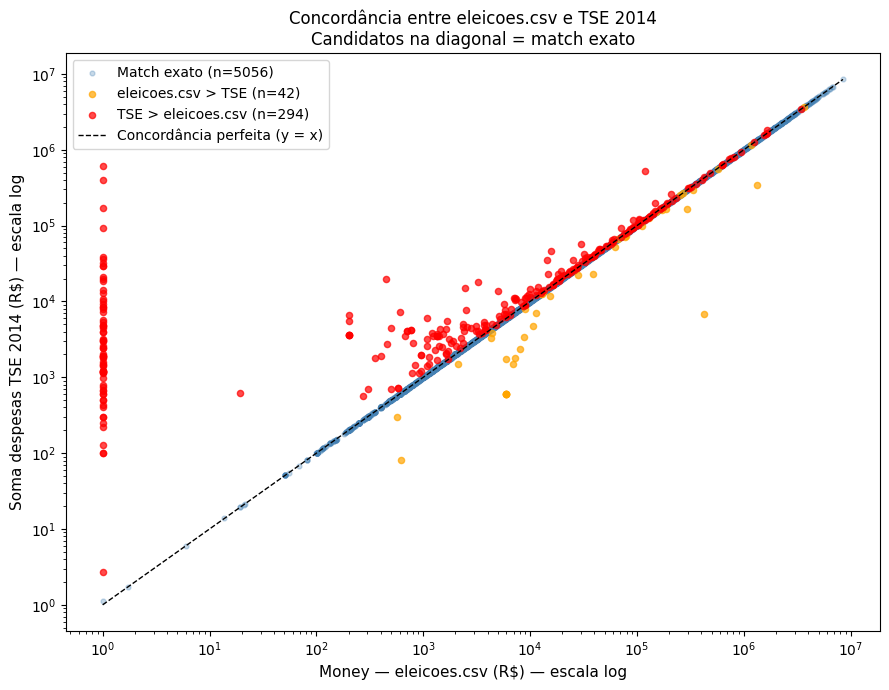

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

# separa em três grupos para colorir o scatter
mask_match  = comparacao["Diferença"] < 1
mask_div_el = (comparacao["Diferença"] >= 1) & (comparacao["Money (R$ Reais)"] > comparacao["Total TSE"])
mask_div_ts = (comparacao["Diferença"] >= 1) & (comparacao["Total TSE"] > comparacao["Money (R$ Reais)"])

match  = comparacao[mask_match]
div_el = comparacao[mask_div_el]
div_ts = comparacao[mask_div_ts]

ax.scatter(match["Money (R$ Reais)"] + 1, match["Total TSE"] + 1,
           color="steelblue", alpha=0.3, s=12, label=f"Match exato (n={len(match)})")
ax.scatter(div_el["Money (R$ Reais)"] + 1, div_el["Total TSE"] + 1,
           color="orange", alpha=0.7, s=20, label=f"eleicoes.csv > TSE (n={len(div_el)})")
ax.scatter(div_ts["Money (R$ Reais)"] + 1, div_ts["Total TSE"] + 1,
           color="red", alpha=0.7, s=20, label=f"TSE > eleicoes.csv (n={len(div_ts)})")

lim_max = max(comparacao["Money (R$ Reais)"].max(), comparacao["Total TSE"].max()) + 1
ax.plot([1, lim_max], [1, lim_max], "k--", linewidth=1, label="Concordância perfeita (y = x)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Money — eleicoes.csv (R$) — escala log", fontsize=11)
ax.set_ylabel("Soma despesas TSE 2014 (R$) — escala log", fontsize=11)
ax.set_title("Concordância entre eleicoes.csv e TSE 2014\nCandidatos na diagonal = match exato", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


O gráfico de concordância plota o valor de `Money` do dataset original (eixo X) contra a soma das despesas do TSE (eixo Y), ambos em escala logarítmica. Candidatos **sobre a linha diagonal** têm valores idênticos nas duas fontes. Candidatos **abaixo** da diagonal são casos onde `eleicoes.csv` registra mais que o TSE; **acima**, o TSE registra mais.

A concentração maciça de pontos azuis sobre a diagonal confirma visualmente o match de 93,73%. a dispersão é pontual e reforça que as divergências são ruído de versão e não um problema estrutural do dataset.

## <font color=blue>3. Análise Exploratória dos Dados

### 3.1 Distribuição do Gasto por Candidato

A distribuição do gasto individual permite entender o perfil financeiro das campanhas. Excluo candidatos com `Money = 0` do histograma pois representam ausência de prestação de contas, não um gasto real de zero reais. O eixo X é exibido em escala logarítmica para acomodar a amplitude entre o menor e o maior gasto.

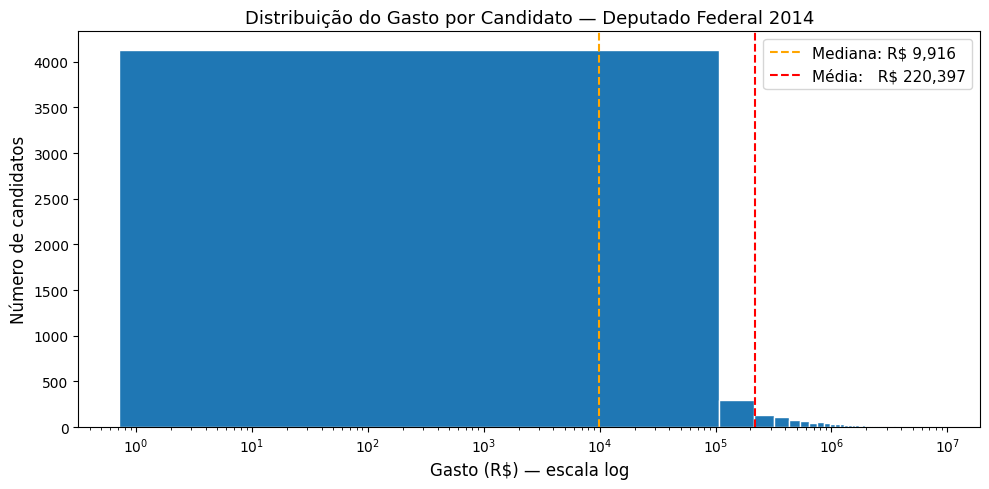

In [11]:
n_bins = np.sqrt(eleicoes_df.shape[0]).astype(int) # total de candidatos para calcular o bin adequado(de acordo com a aula)

mask_com_gasto = eleicoes_enriquecido["Money (R$ Reais)"] > 0
gastos = eleicoes_enriquecido[mask_com_gasto]["Money (R$ Reais)"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gastos, bins=n_bins, edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log", fontsize=12)
ax.set_ylabel("Número de candidatos", fontsize=12)
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014", fontsize=13)
ax.axvline(gastos.median(), color="orange", linestyle="--", linewidth=1.5, label=f"Mediana: R$ {gastos.median():,.0f}")
ax.axvline(gastos.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Média:   R$ {gastos.mean():,.0f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


A distribuição é fortemente assimétrica à direita. A mediana de R$ 9.916 representa o candidato típico, aquele que está no centro da distribuição, e revela que a maioria dos candidatos gastou relativamente pouco em campanha. Já a média de R$ 220.397 é puxada para cima por um pequeno grupo de candidatos com gastos muito elevados, chegando a R$ 8,4 milhões no caso mais extremo. A distância entre essas duas medidas de tendência central evidencia a concentração de recursos: quando média e mediana se afastam tanto, é sinal de que poucos concentram muito. Esse padrão é típico em financiamento eleitoral e sugere que o gasto de campanha não é igualmente distribuído entre os concorrentes.

### 3.2 Gasto por Estado

#### 3.2.1 Gasto total por Estado


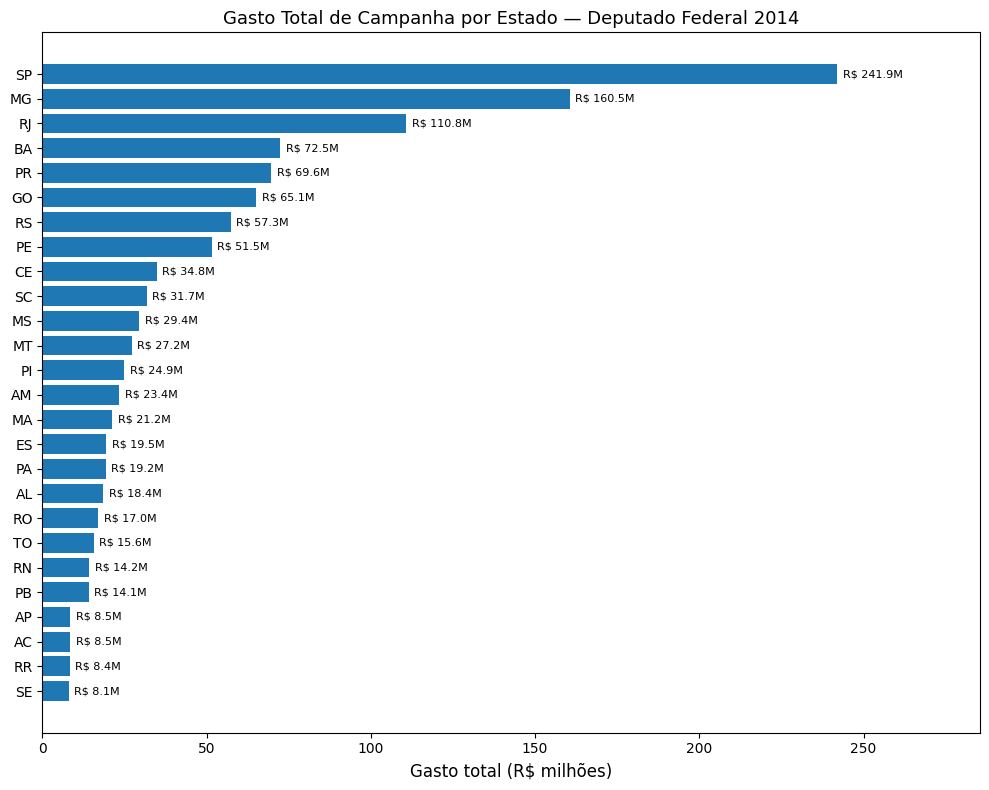

In [12]:
total_estado = (
    eleicoes_enriquecido
    .groupby("State")["Money (R$ Reais)"]
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(total_estado.index, total_estado.values / 1e6)
ax.set_xlabel("Gasto total (R$ milhões)", fontsize=12)
ax.set_title("Gasto Total de Campanha por Estado — Deputado Federal 2014", fontsize=13)
ax.bar_label(bars, fmt="R$ %.1fM", padding=4, fontsize=8)
ax.set_xlim(0, total_estado.max() / 1e6 * 1.18)
plt.tight_layout()
plt.show()


SP (R$ 242M), MG (R$ 160M) e RJ (R$ 111M) lideram com folga. Os três estados mais populosos do país juntos elegem 162 dos 513 deputados federais. A concentração de recursos nesses estados reflete tanto o maior número de candidatos quanto o custo mais elevado de campanha em mercados publicitários maiores.

#### 3.2.2 Gasto médio por Estado

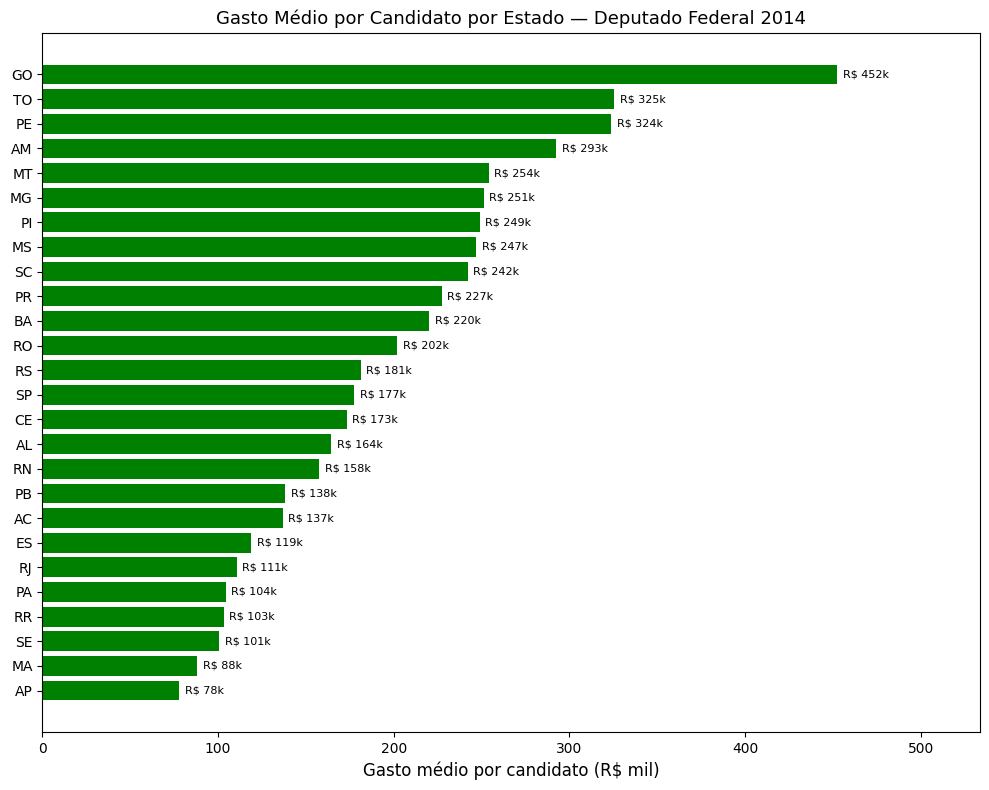

In [13]:
media_estado = (
    eleicoes_enriquecido
    .groupby("State")["Money (R$ Reais)"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(media_estado.index, media_estado.values / 1e3, color="green")
ax.set_xlabel("Gasto médio por candidato (R$ mil)", fontsize=12)
ax.set_title("Gasto Médio por Candidato por Estado — Deputado Federal 2014", fontsize=13)
ax.bar_label(bars, fmt="R$ %.0fk", padding=4, fontsize=8)
ax.set_xlim(0, media_estado.max() / 1e3 * 1.18)
plt.tight_layout()
plt.show()


Ao observar a média, o ranking muda completamente: GO, TO, PE, AM e MT lideram, enquanto SP cai para posições intermediárias. Isso indica que em estados menores, com menos vagas disponíveis, a disputa por cada cadeira é mais acirrada e os candidatos competitivos precisam gastar mais individualmente para se destacar num eleitorado proporcionalmente menor.

### 3.3 Gasto por Partido (Top 10)



#### 3.3.1 Total por Partido

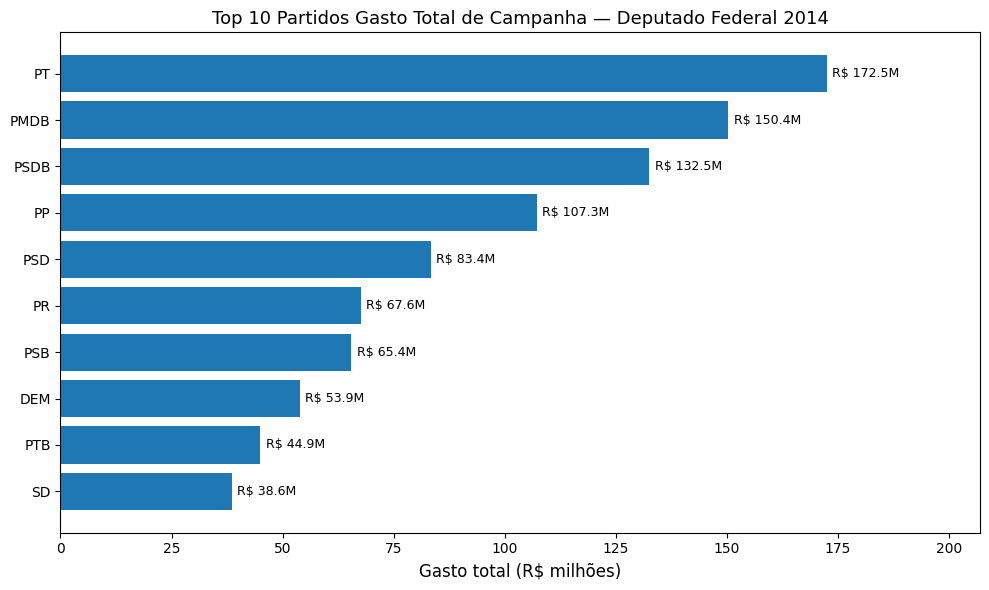

In [14]:
top10_total_partido = (
    eleicoes_enriquecido
    .groupby("Partido")["Money (R$ Reais)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_total_partido.index, top10_total_partido.values / 1e6)
ax.set_xlabel("Gasto total (R$ milhões)", fontsize=12)
ax.set_title("Top 10 Partidos Gasto Total de Campanha — Deputado Federal 2014", fontsize=13)
ax.bar_label(bars, fmt="R$ %.1fM", padding=4, fontsize=9)
ax.set_xlim(0, top10_total_partido.max() / 1e6 * 1.2)
plt.tight_layout()
plt.show()


O ranking de gasto total é dominado pelos grandes partidos nacionais: PT, PMDB, PSDB e PP, que em 2014 compunham o centro do espectro político e tinham acesso privilegiado ao fundo partidário proporcional à representação no Congresso.

#### 3.3.2 Média por Partido


O gasto médio por candidato revela quais partidos investem mais por cabeça. Um partido pequeno que não entrou no gráfico passado pode entrar nesse por investir mais dinheiro em seus candidatos.

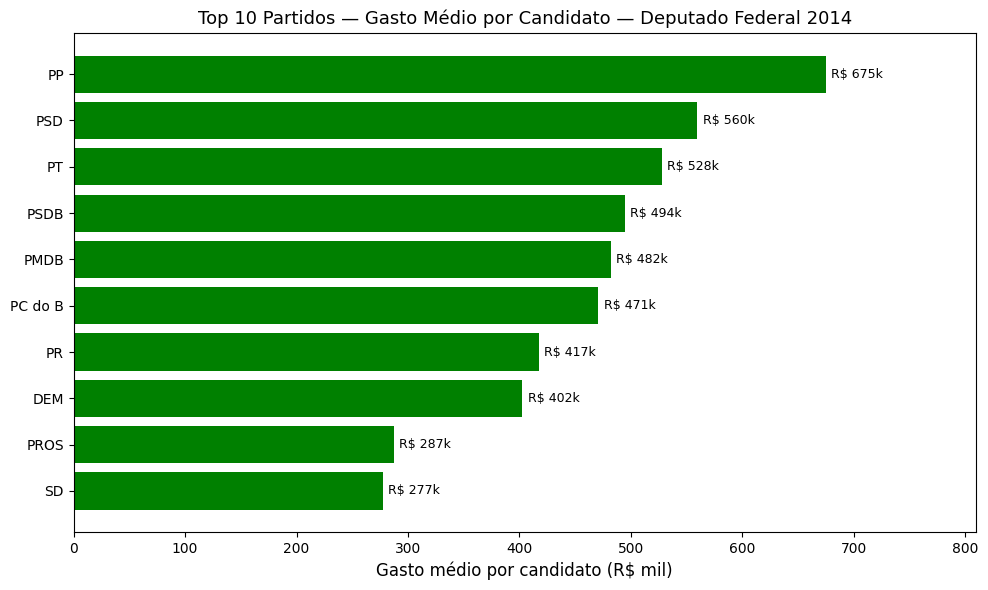

In [15]:
mask_partido_valido = eleicoes_enriquecido["Partido"].notna()

top10_media_partido = (
    eleicoes_enriquecido[mask_partido_valido]
    .groupby("Partido")["Money (R$ Reais)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_media_partido.index, top10_media_partido.values / 1e3, color="green")
ax.set_xlabel("Gasto médio por candidato (R$ mil)", fontsize=12)
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014", fontsize=13)
ax.bar_label(bars, fmt="R$ %.0fk", padding=4, fontsize=9)
ax.set_xlim(0, top10_media_partido.max() / 1e3 * 1.2)
plt.tight_layout()
plt.show()


O gasto médio por candidato tende a revelar partidos que concentram recursos em poucos candidatos estratégicos ao invés de distribuí-los amplamente. Partidos que aparecem aqui mas não no ranking de total provavelmente lançaram menos candidatos, porém com campanhas mais robustas.

### 3.4 Gasto vs Votos por Situação Eleitoral

No scatter a seguir, cruzo gasto e votos de cada candidato, colorindo pelo resultado eleitoral. Excluo candidatos com `Money = 0` ou `Votes = 0` para não distorcer as escalas logarítmicas. As categorias `ELEITO POR QP` e `ELEITO POR MÉDIA` são agrupadas em **Eleito** por representarem o mesmo desfecho.

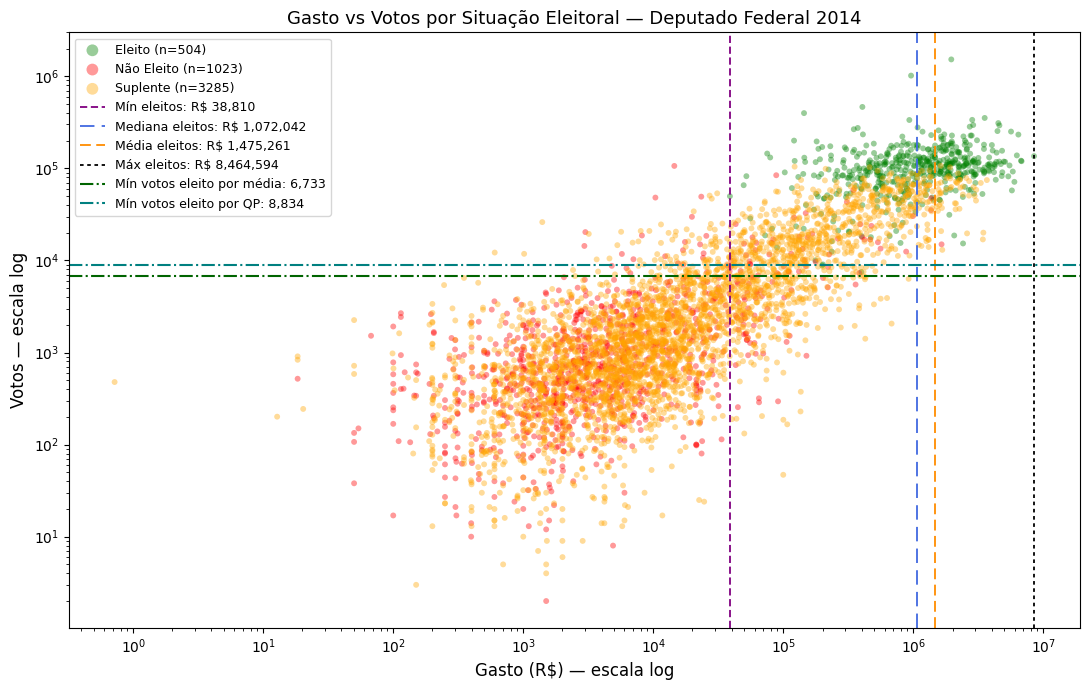

In [16]:
situacao_map = {
    "ELEITO POR QP":    "Eleito",
    "ELEITO POR MÉDIA": "Eleito",
    "SUPLENTE":         "Suplente",
    "NÃO ELEITO":       "Não Eleito",
}
cores = {"Eleito": "green", "Suplente": "orange", "Não Eleito": "red"}

# filtra candidatos com gasto, votos e situação eleitoral conhecidos
mask_tem_gasto    = eleicoes_enriquecido["Money (R$ Reais)"] > 0
mask_tem_votos    = eleicoes_enriquecido["Votes"] > 0
mask_situacao_val = eleicoes_enriquecido["Situacao"].isin(situacao_map)

scatter_df = eleicoes_enriquecido[mask_tem_gasto & mask_tem_votos & mask_situacao_val].copy()
scatter_df["Resultado"] = scatter_df["Situacao"].map(situacao_map)

# Linhas verticais — limiares de gasto dos eleitos
mask_eleitos   = scatter_df["Resultado"] == "Eleito"
eleitos_money  = scatter_df[mask_eleitos]["Money (R$ Reais)"]

refs_verticais = {
    "Mín eleitos":     (eleitos_money.min(),    "purple",      (4, 2)),
    "Mediana eleitos": (eleitos_money.median(), "royalblue",   (8, 4)),
    "Média eleitos":   (eleitos_money.mean(),   "darkorange",  (6, 3)),
    "Máx eleitos":     (eleitos_money.max(),    "black",       (2, 2)),
}

# Linhas horizontais — mínimo de votos por tipo de eleição
min_votos_media = (
    eleicoes_enriquecido[eleicoes_enriquecido["Situacao"] == "ELEITO POR MÉDIA"]["Votes"].min()
)
min_votos_qp = (
    eleicoes_enriquecido[eleicoes_enriquecido["Situacao"] == "ELEITO POR QP"]["Votes"].min()
)

fig, ax = plt.subplots(figsize=(11, 7))

for resultado, grupo in scatter_df.groupby("Resultado"):
    ax.scatter(
        grupo["Money (R$ Reais)"],
        grupo["Votes"],
        c=cores[resultado],
        label=f"{resultado} (n={len(grupo)})",
        alpha=0.4,
        s=18,
        edgecolors="none",
    )

for label, (valor, cor, dash) in refs_verticais.items():
    ax.axvline(valor, color=cor, linestyle="--", linewidth=1.3, dashes=dash,
               label=f"{label}: R$ {valor:,.0f}")

ax.axhline(min_votos_media, color="darkgreen", linestyle="-.", linewidth=1.5,
           label=f"Mín votos eleito por média: {min_votos_media:,}")
ax.axhline(min_votos_qp, color="teal", linestyle="-.", linewidth=1.5,
           label=f"Mín votos eleito por QP: {min_votos_qp:,}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Gasto (R$) — escala log", fontsize=12)
ax.set_ylabel("Votos — escala log", fontsize=12)
ax.set_title("Gasto vs Votos por Situação Eleitoral — Deputado Federal 2014", fontsize=13)
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()


O gráfico revela uma separação entre os grupos: candidatos eleitos (verde) concentram-se na região superior direita, alto gasto e muitos votos. enquanto os não eleitos (vermelho) se acumulam no canto inferior esquerdo. Os suplentes (laranja) ocupam uma faixa intermediária. existe a tendência positiva entre gasto e votos, mas a dispersão também mostra que gasto elevado não garante eleição: há candidatos com alto investimento entre os não eleitos, e alguns eleitos com gasto moderado. O dinheiro é condição importante, mas não suficiente.

### 3.5 Gasto por Variáveis Qualitativas





Para cada variável qualitativa demográfica (Gênero, Escolaridade e Raça), apresento três tipos de visualização:

1. **Representatividade**: gráfico de barras comparando a proporção de candidatos de cada categoria com a proporção do gasto total que essa categoria representa. Permite identificar se algum grupo concentra mais recursos do que sua presença numérica.

2. **Distribuição do gasto**: box plot em escala logarítmica mostrando a dispersão dos gastos dentro de cada categoria. Excluo candidatos com `Money = 0` para focar na distribuição real dos gastos declarados.

3. **Resultado eleitoral**: dois gráficos lado a lado. (a) barras empilhadas com a taxa de eleitos, suplentes e não eleitos por categoria. e (b) barras agrupadas com o gasto médio por desfecho eleitoral e categoria.

#### 3.5.0 Funções genéricas de plot

In [17]:
# segreguei algumas funcoes para melhorar legibilidade dos codigos. ja que todo o trabalho deve estar em um unico arquivo

ordem_escolaridade = [
    "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO",
    "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO",
    "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO",
    "SUPERIOR COMPLETO",
]

def plot_representatividade(df, coluna, titulo, ax):
    total_cand = df[coluna].value_counts(normalize=True) * 100
    total_gasto = df.groupby(coluna)["Money (R$ Reais)"].sum()
    total_gasto = (total_gasto / total_gasto.sum()) * 100
    categorias = total_cand.index.tolist()
    x = range(len(categorias))
    w = 0.35
    bars1 = ax.bar([i - w/2 for i in x], [total_cand[c] for c in categorias], width=w,
                   label="% de candidatos", color="steelblue", alpha=0.8)
    bars2 = ax.bar([i + w/2 for i in x], [total_gasto.get(c, 0) for c in categorias], width=w,
                   label="% do gasto total", color="seagreen", alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(categorias, rotation=20, ha="right")
    ax.set_ylabel("Percentual (%)")
    ax.set_title(titulo)
    ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=8)
    ax.legend()


def plot_boxplot_gasto(df, coluna, categorias, titulo, cor="steelblue", figsize=(10, 5), labels=None):
    box_df = df[df["Money (R$ Reais)"] > 0]
    dados = [box_df[box_df[coluna] == c]["Money (R$ Reais)"].dropna() for c in categorias]
    labels = labels or categorias
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(dados, tick_labels=labels, patch_artist=True,
               boxprops=dict(facecolor=cor, alpha=0.6),
               medianprops=dict(color="black", linewidth=2))
    ax.set_yscale("log")
    ax.set_ylabel("Gasto (R$) — escala log", fontsize=12)
    ax.set_title(f"Distribuição do Gasto por {titulo} — Deputado Federal 2014", fontsize=13)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    for label, d in zip(labels, dados):
        print(f"{label}: mediana = R$ {d.median():,.0f} | n = {len(d)}")


def plot_eleicao_por_variavel(df, coluna, categorias, titulo, figsize=(13, 5)):
    df = df.copy()
    df["Resultado"] = df["Situacao"].map({
        "ELEITO POR QP":    "Eleito",
        "ELEITO POR MÉDIA": "Eleito",
        "SUPLENTE":         "Suplente",
        "NÃO ELEITO":       "Não Eleito",
    })
    df = df[df["Resultado"].notna() & df[coluna].notna()]

    proporcoes = (
        df.groupby([coluna, "Resultado"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Eleito", "Suplente", "Não Eleito"], fill_value=0)
    )
    proporcoes = proporcoes.div(proporcoes.sum(axis=1), axis=0) * 100
    proporcoes = proporcoes.reindex(categorias)

    gasto_medio = (
        df.groupby([coluna, "Resultado"])["Money (R$ Reais)"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=["Eleito", "Suplente", "Não Eleito"], fill_value=0)
        .reindex(categorias)
    )

    cores_resultado = {"Eleito": "green", "Suplente": "orange", "Não Eleito": "red"}
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    bottom = [0] * len(categorias)
    for resultado in ["Eleito", "Suplente", "Não Eleito"]:
        vals = proporcoes[resultado].tolist()
        ax1.bar(range(len(categorias)), vals, bottom=bottom,
                label=resultado, color=cores_resultado[resultado], alpha=0.8)
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax1.set_xticks(range(len(categorias)))
    ax1.set_xticklabels(categorias, rotation=20, ha="right", fontsize=9)
    ax1.set_ylabel("% de candidatos")
    ax1.set_title(f"Resultado eleitoral por {titulo}")
    ax1.legend(loc="upper right", fontsize=8)

    x = range(len(categorias))
    w = 0.28
    for i, resultado in enumerate(["Eleito", "Suplente", "Não Eleito"]):
        vals = (gasto_medio[resultado] / 1e3).tolist()
        ax2.bar([xi + (i - 1) * w for xi in x], vals, width=w,
                label=resultado, color=cores_resultado[resultado], alpha=0.8)
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(categorias, rotation=20, ha="right", fontsize=9)
    ax2.set_ylabel("Gasto médio (R$ mil)")
    ax2.set_title(f"Gasto médio por resultado — {titulo}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


#### 3.5.1 Gênero


Antes de comparar os gastos, busco entender como homens e mulheres estão distribuídos no total de candidatos e no total de recursos gastos. A diferença entre essas duas proporções revela se um grupo gasta proporcionalmente mais ou menos do que sua representação numérica sugeriria.

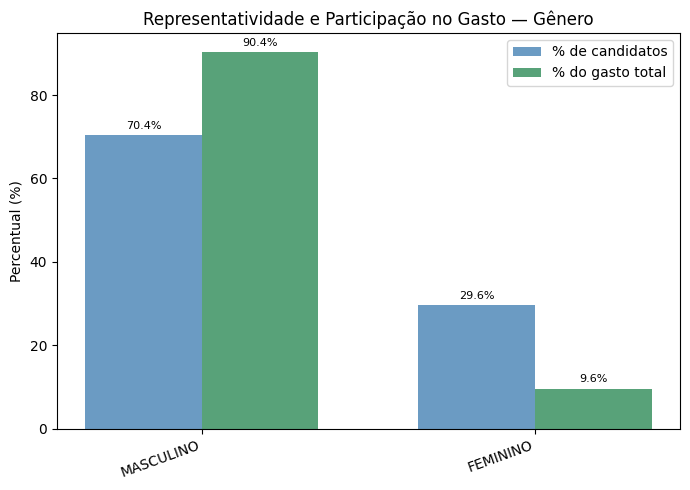

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_representatividade(eleicoes_enriquecido, "Genero",
                        "Representatividade e Participação no Gasto — Gênero", ax)
plt.tight_layout()
plt.show()


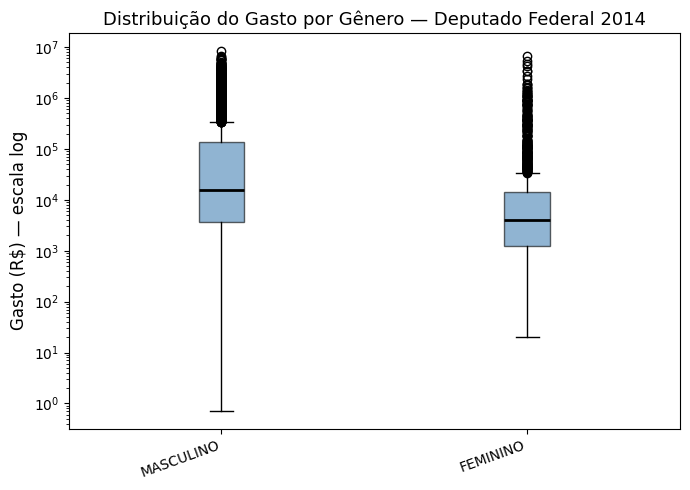

MASCULINO: mediana = R$ 15,726 | n = 3820
FEMININO: mediana = R$ 4,000 | n = 1500


In [19]:
plot_boxplot_gasto(eleicoes_enriquecido, "Genero",
                   categorias=["MASCULINO", "FEMININO"],
                   titulo="Gênero", figsize=(7, 5))


In [20]:
stats_genero = (
    eleicoes_enriquecido
    .groupby("Genero")["Money (R$ Reais)"]
    .agg(
        N="count",
        Mediana="median",
        Media="mean",
    )
    .rename(index={"MASCULINO": "Masculino", "FEMININO": "Feminino"})
)

display(stats_genero.style
    .format({"N": "{:,.0f}", "Mediana": "R$ {:,.0f}", "Media": "R$ {:,.0f}"})
    .set_caption("Tabela — Distribuição de candidatos e gasto por Gênero"))

,N,Mediana,Media
Genero,,,
Feminino,"1,879","R$ 2,003","R$ 59,939"
Masculino,"4,470","R$ 9,299","R$ 237,258"


Candidatos masculinos tendem a gastar mais do que candidatas femininas, tanto na mediana quanto na média. Essa diferença pode refletir a desigualdade estrutural no acesso a financiamento de campanha. O fato de que candidatos masculinos representam 70% do total pode influenciar esse resultado, quase uma certeza.

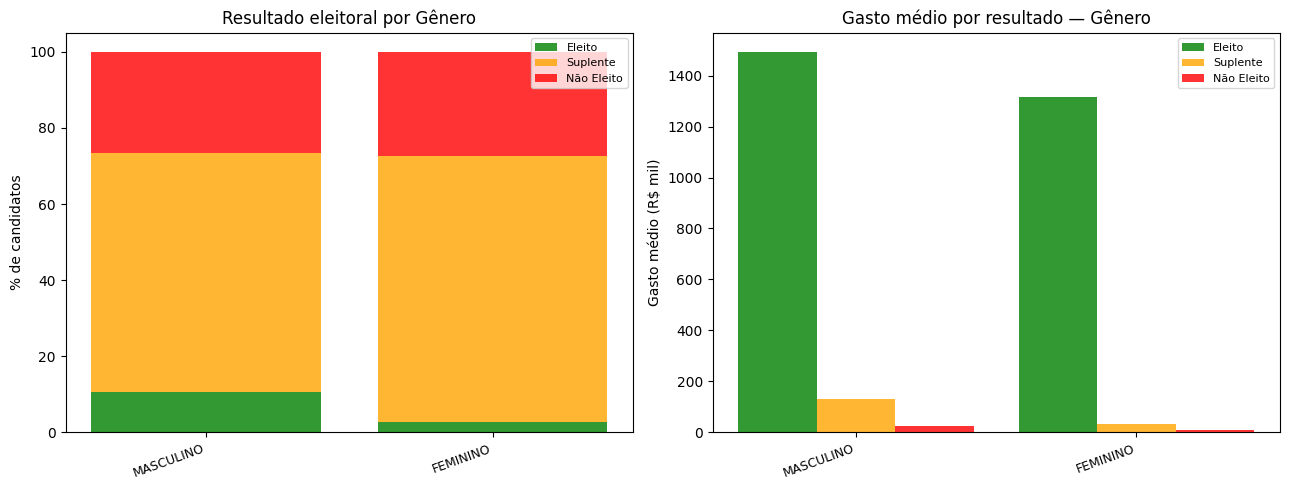

In [21]:
plot_eleicao_por_variavel(
    eleicoes_enriquecido, "Genero",
    categorias=["MASCULINO", "FEMININO"],
    titulo="Gênero"
)


Com a distribuição de gastos estabelecida, analiso agora o desfecho eleitoral por gênero: qual a taxa de eleição de homens e mulheres, e qual o gasto médio de quem foi eleito em cada grupo?

O gráfico da esquerda mostra a taxa de eleição dentro de cada gênero. o da direita compara o gasto médio de eleitos, suplentes e não eleitos separadamente por gênero, revelando se mulheres eleitas precisam gastar mais ou menos que homens eleitos para obter o mesmo resultado.

#### 3.5.2 Escolaridade


A escolaridade divide os candidatos em sete níveis. Verifiquei primeiro qual a representação de cada nível no total de candidatos e qual a fatia de gasto que concentra, respondendo perguntas do tipo: candidatos com nível superior são maioria? E gastam proporcionalmente mais ou menos do que representam?

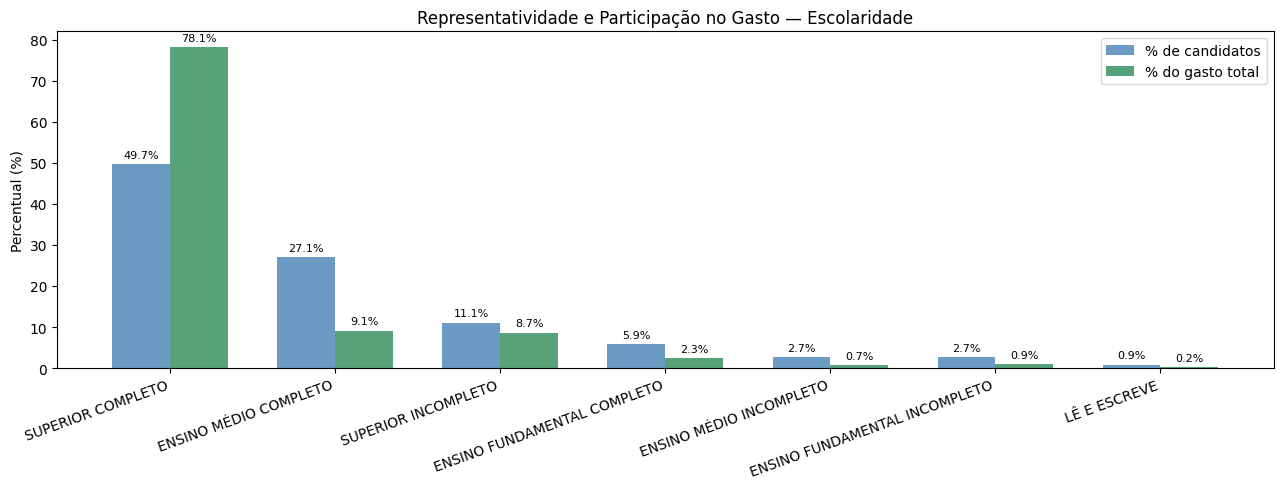

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_representatividade(eleicoes_enriquecido, "Escolaridade",
                        "Representatividade e Participação no Gasto — Escolaridade", ax)
plt.tight_layout()
plt.show()


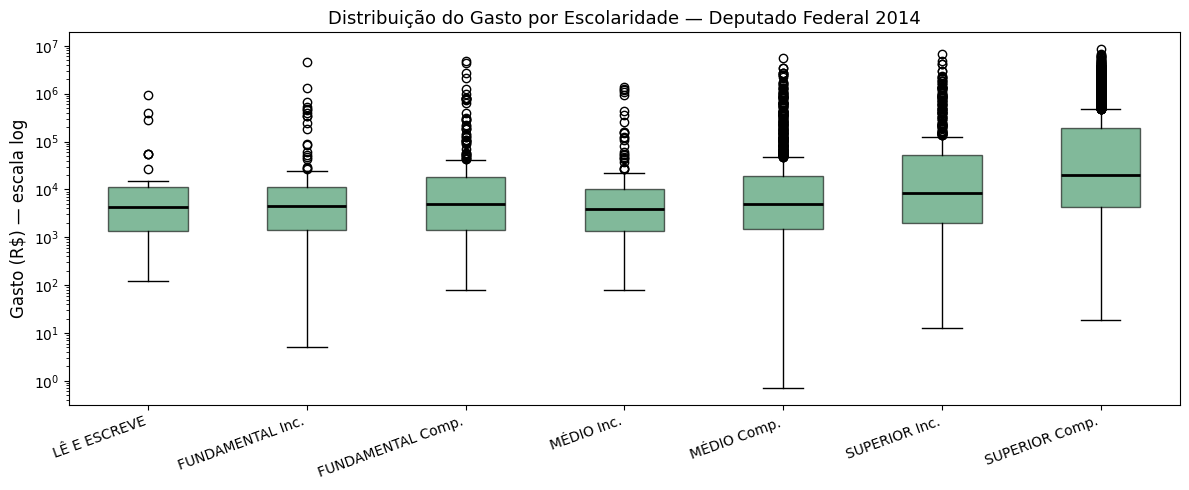

LÊ E ESCREVE: mediana = R$ 4,205 | n = 35
FUNDAMENTAL Inc.: mediana = R$ 4,477 | n = 131
FUNDAMENTAL Comp.: mediana = R$ 5,000 | n = 288
MÉDIO Inc.: mediana = R$ 3,916 | n = 138
MÉDIO Comp.: mediana = R$ 5,000 | n = 1333
SUPERIOR Inc.: mediana = R$ 8,301 | n = 574
SUPERIOR Comp.: mediana = R$ 20,407 | n = 2821


In [23]:
labels_esc = [e.replace("ENSINO ", "").replace(" COMPLETO", " Comp.").replace(" INCOMPLETO", " Inc.")
              for e in ordem_escolaridade]

plot_boxplot_gasto(eleicoes_enriquecido, "Escolaridade",
                   categorias=ordem_escolaridade, labels=labels_esc,
                   titulo="Escolaridade", cor="seagreen", figsize=(12, 5))


In [24]:
stats_esc = (
    eleicoes_enriquecido
    .groupby("Escolaridade")["Money (R$ Reais)"]
    .agg(
        N="count",
        Mediana="median",
        Media="mean",
    )
    .reindex(ordem_escolaridade)
)

display(stats_esc.style
    .format({"N": "{:,.0f}", "Mediana": "R$ {:,.0f}", "Media": "R$ {:,.0f}"})
    .set_caption("Tabela — Distribuição de candidatos e gasto por Escolaridade"))

,N,Mediana,Media
Escolaridade,,,
LÊ E ESCREVE,55,"R$ 1,088","R$ 35,268"
ENSINO FUNDAMENTAL INCOMPLETO,169,"R$ 1,874","R$ 62,587"
ENSINO FUNDAMENTAL COMPLETO,376,"R$ 2,301","R$ 73,096"
ENSINO MÉDIO INCOMPLETO,173,"R$ 2,089","R$ 49,921"
ENSINO MÉDIO COMPLETO,"1,719","R$ 2,396","R$ 62,228"
SUPERIOR INCOMPLETO,704,"R$ 4,260","R$ 144,170"
SUPERIOR COMPLETO,"3,153","R$ 13,751","R$ 290,538"


Há uma relação positiva entre escolaridade e gasto: candidatos com ensino superior completo têm mediana e média de gasto significativamente maiores (R$ ~290k) do que candidatos com menor escolaridade (R$ ~35 a 73k). Isso pode indicar que candidatos com maior nível educacional têm redes de relacionamento e acesso a financiadores que candidatos com menos escolaridade não têm, ou que o perfil socioeconômico mais elevado já traz consigo maior capacidade de arrecadação.

Analiso agora como a escolaridade se relaciona com o resultado eleitoral: candidatos com mais escolaridade têm maior taxa de eleição? E entre os eleitos, o gasto médio varia conforme o nível educacional?

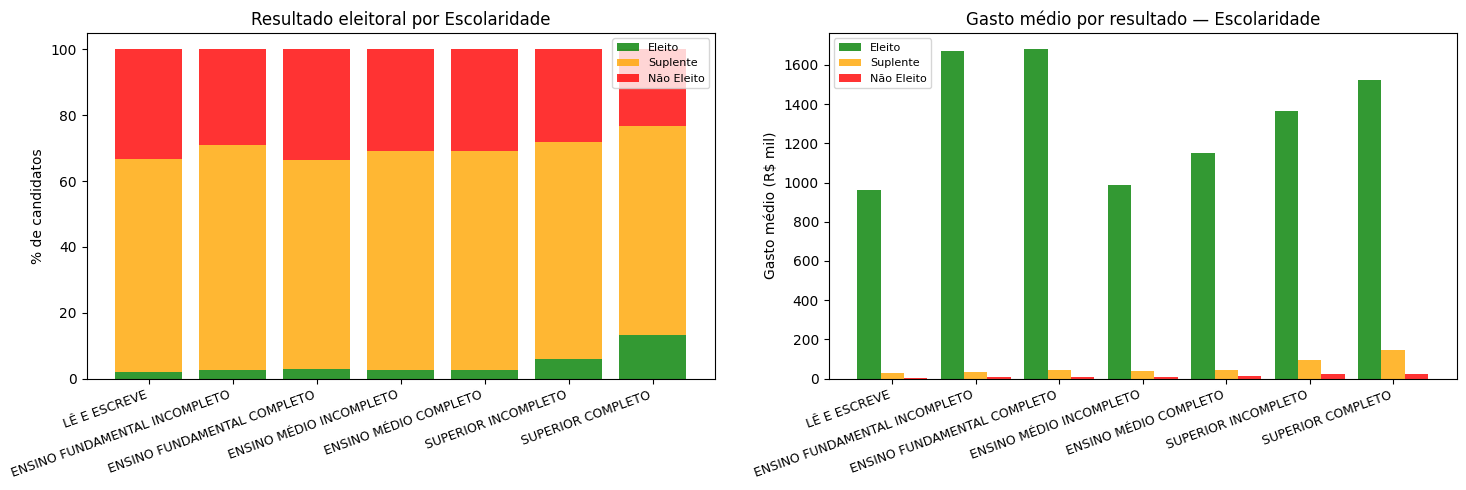

In [25]:
plot_eleicao_por_variavel(
    eleicoes_enriquecido, "Escolaridade",
    categorias=ordem_escolaridade,
    titulo="Escolaridade",
    figsize=(15, 5)
)


Candidatos com ensino superior completo dominam tanto em taxa de eleição quanto em gasto médio entre os eleitos, o que levanta a questão se a escolaridade em si confere vantagem eleitoral ou se ela é um proxy do nível socioeconômico, que por sua vez determina o acesso a recursos de campanha. Grupos com menor escolaridade, mesmo quando eleitos, tendem a ter campanhas menos custosas, possivelmente apoiadas em capital político e redes locais em vez de investimento financeiro.

#### 3.5.3 Raça


O Brasil tem uma população majoritariamente parda e preta, mas historicamente sub-representada na política. Verifico aqui qual a composição racial dos candidatos a Deputado Federal em 2014 e como cada grupo participa do total de recursos gastos.

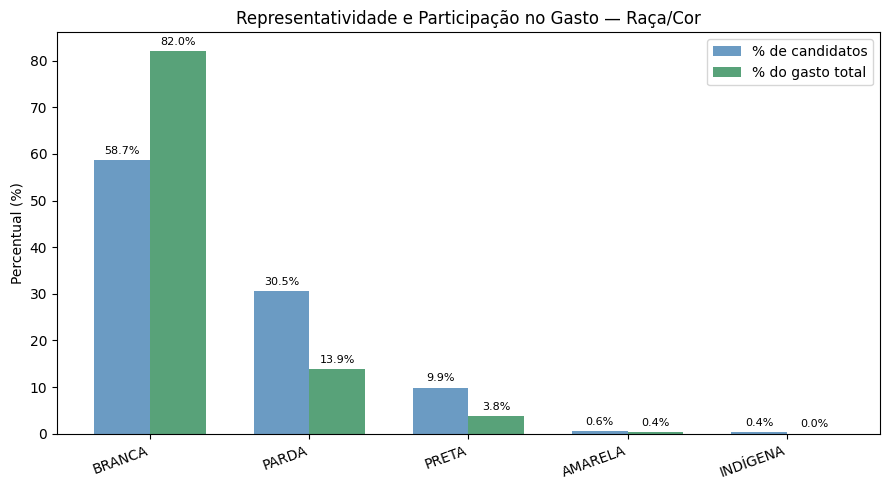

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_representatividade(eleicoes_enriquecido, "Raca",
                        "Representatividade e Participação no Gasto — Raça/Cor", ax)
plt.tight_layout()
plt.show()


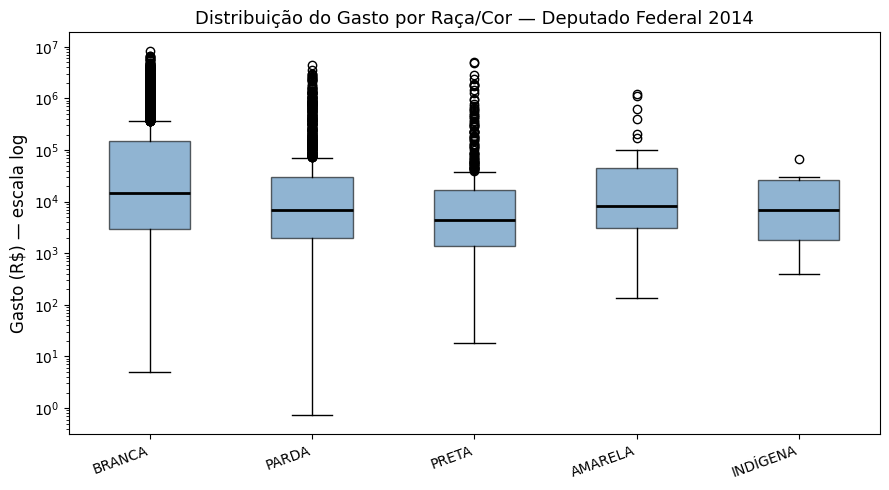

BRANCA: mediana = R$ 14,660 | n = 3215
PARDA: mediana = R$ 6,888 | n = 1554
PRETA: mediana = R$ 4,393 | n = 501
AMARELA: mediana = R$ 8,392 | n = 34
INDÍGENA: mediana = R$ 6,999 | n = 16


In [27]:
plot_boxplot_gasto(eleicoes_enriquecido, "Raca",
                   categorias=["BRANCA", "PARDA", "PRETA", "AMARELA", "INDÍGENA"],
                   titulo="Raça/Cor", figsize=(9, 5))


Candidatos brancos tendem a concentrar maiores gastos de campanha em comparação a pardos e pretos, refletindo as desigualdades estruturais de acesso a capital e redes de financiamento no Brasil. Categorias com poucos candidatos (Amarela e Indígena) devem ser interpretadas com cautela pela baixa representatividade amostral. A disparidade racial no financiamento eleitoral é um reflexo direto das desigualdades socioeconômicas mais amplas da sociedade brasileira.

Por fim, cruzo raça com resultado eleitoral e gasto: grupos raciais sub-representados entre os candidatos também têm menor taxa de eleição? E candidatos negros e pardos eleitos gastam proporcionalmente mais ou menos que candidatos brancos eleitos?

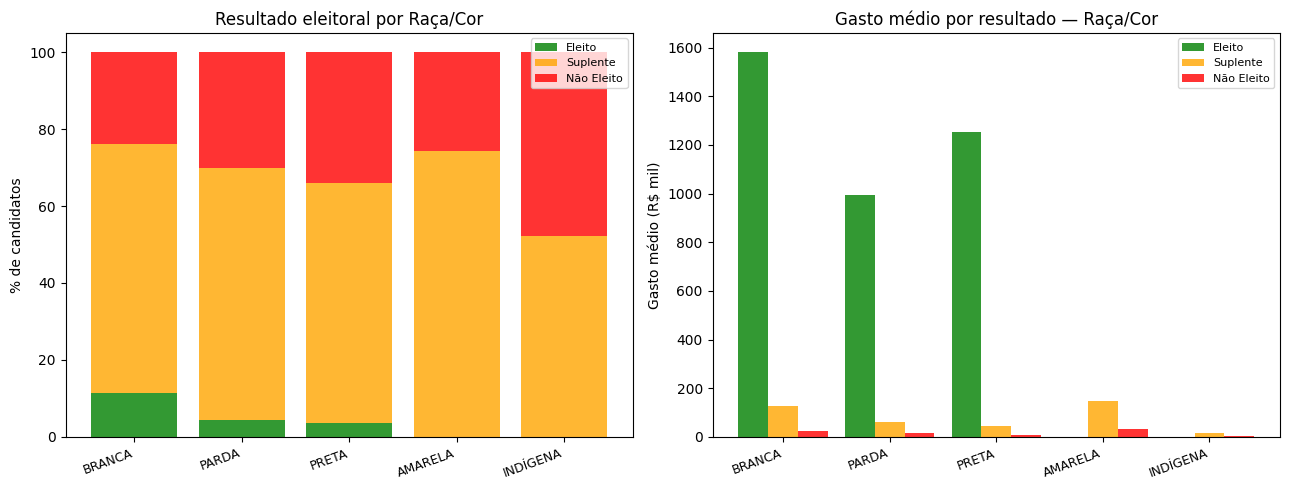

In [28]:
plot_eleicao_por_variavel(
    eleicoes_enriquecido, "Raca",
    categorias=["BRANCA", "PARDA", "PRETA", "AMARELA", "INDÍGENA"],
    titulo="Raça/Cor",
    figsize=(13, 5)
)


A análise racial revela uma dupla desvantagem: candidatos pardos e pretos não apenas são sub-representados no total de candidatos em relação à composição da população brasileira, como também tendem a ter taxas de eleição menores e gastos médios mais baixos, mesmo entre os eleitos. Isso evidencia que as desigualdades raciais permeiam todo o ciclo eleitoral: do acesso à candidatura ao financiamento e ao resultado final nas urnas. Categorias com poucos candidatos (Amarela, Indígena) devem ser interpretadas com cautela dada a baixa representatividade amostral.

## <font color=blue> 4. Síntese e Conclusões


Nesta seção, reúno as principais medidas descritivas da análise em tabelas resumo, oferecendo o embasamento quantitativo para as inferências sobre o financiamento de campanhas e o resultado eleitoral dos Deputados Federais em 2014.

### 4.1 Perfil Financeiro Geral das Campanhas


Medidas de posição e dispersão do gasto e dos votos para o universo completo de candidatos. Incluo candidatos com `Money = 0` para refletir a realidade do campo eleitoral.

In [29]:
resumo = pd.DataFrame({
    "Gasto (R$)": eleicoes_enriquecido["Money (R$ Reais)"],
    "Votos":       eleicoes_enriquecido["Votes"],
}).agg(["count", "mean", "median", "std", "min", "max"]).T

resumo.columns = ["N", "Média", "Mediana", "Desvio Padrão", "Mínimo", "Máximo"]
resumo.insert(6, "Assimetria", [
    skew(eleicoes_enriquecido["Money (R$ Reais)"]),
    skew(eleicoes_enriquecido["Votes"]),
])
resumo["Razão Média/Mediana"] = resumo["Média"] / resumo["Mediana"]

display(resumo.style
    .format({"N": "{:,.0f}", "Média": "R$ {:,.0f}", "Mediana": "R$ {:,.0f}",
             "Desvio Padrão": "R$ {:,.0f}", "Mínimo": "R$ {:,.0f}", "Máximo": "R$ {:,.0f}",
             "Assimetria": "{:.2f}", "Razão Média/Mediana": "{:.1f}x"})
    .set_caption("Tabela 4.1 — Medidas descritivas de Gasto e Votos"))


,N,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Assimetria,Razão Média/Mediana
Gasto (R$),"6,353","R$ 184,665","R$ 5,804","R$ 584,669",R$ 0,"R$ 8,464,594",5.40,31.8x
Votos,"6,353","R$ 13,813",R$ 976,"R$ 41,476",R$ 0,"R$ 1,524,361",12.26,14.2x


A assimetria de **5,40** no gasto confirma uma distribuição extremamente concentrada: a média (R$ 184k) é **32x** maior que a mediana (R$ 5.8k), revelando que uma minoria de candidatos muito bem financiados distorce completamente a média. O desvio padrão supera a própria média, sinalizando alta variabilidade e a presença de outliers significativos no extremo superior.


### 4.2 Gasto e Resultado Eleitoral



Comparação das medidas de posição e dispersão do gasto e dos votos segmentada pelo resultado eleitoral.

In [30]:
res_df = eleicoes_enriquecido.copy()
res_df["Resultado"] = res_df["Situacao"].map({
    "ELEITO POR QP": "Eleito", "ELEITO POR MÉDIA": "Eleito",
    "SUPLENTE": "Suplente", "NÃO ELEITO": "Não Eleito",
})
res_df = res_df[res_df["Resultado"].notna()]

tabela_resultado = res_df.groupby("Resultado").agg(
    N=("Money (R$ Reais)", "count"),
    Gasto_Medio=("Money (R$ Reais)", "mean"),
    Gasto_Mediana=("Money (R$ Reais)", "median"),
    Gasto_DP=("Money (R$ Reais)", "std"),
    Votos_Medio=("Votes", "mean"),
    Votos_Mediana=("Votes", "median"),
).reindex(["Eleito", "Suplente", "Não Eleito"])

tabela_resultado["Razão Gasto vs Não Eleito"] = (
    tabela_resultado["Gasto_Medio"] / tabela_resultado.loc["Não Eleito", "Gasto_Medio"]
).map("{:.0f}x".format)

tabela_resultado.columns = ["N", "Gasto Médio", "Gasto Mediana", "Gasto DP",
                             "Votos Médios", "Votos Mediana", "Razão vs Não Eleito"]

display(tabela_resultado.style
    .format({"N": "{:,.0f}", "Gasto Médio": "R$ {:,.0f}", "Gasto Mediana": "R$ {:,.0f}",
             "Gasto DP": "R$ {:,.0f}", "Votos Médios": "{:,.0f}", "Votos Mediana": "{:,.0f}"})
    .set_caption("Tabela 4.2 — Gasto e Votos por Resultado Eleitoral"))


,N,Gasto Médio,Gasto Mediana,Gasto DP,Votos Médios,Votos Mediana,Razão vs Não Eleito
Resultado,,,,,,,
Eleito,504,"R$ 1,475,261","R$ 1,072,042","R$ 1,311,267","113,917","102,866",77x
Suplente,"3,907","R$ 100,551","R$ 7,700","R$ 307,142","7,049","1,269",5x
Não Eleito,"1,619","R$ 19,212","R$ 1,985","R$ 87,554","1,647",399,1x


A separação entre grupos é contundente: candidatos eleitos gastam em média **77x mais** que os não eleitos (R$ 1,47M vs R$ 19k) e obtêm **69x mais votos** na mediana. A alta dispersão entre os próprios eleitos (DP de R$ 1,3M) indica que não há um "valor mínimo de entrada" fixo: candidatos com forte capital político podem vencer com menos recursos, enquanto outros precisam de campanhas milionárias para competir.



### 4.3 Desigualdades Demográficas no Financiamento



#### 4.3.1 Gênero

In [31]:
def tabela_demografica(df, coluna, categorias):
    res = df.copy()
    res["Resultado"] = res["Situacao"].map({
        "ELEITO POR QP": "Eleito", "ELEITO POR MÉDIA": "Eleito",
        "SUPLENTE": "Suplente", "NÃO ELEITO": "Não Eleito",
    })
    total_gasto = res["Money (R$ Reais)"].sum()
    rows = []
    for cat in categorias:
        sub = res[res[coluna] == cat]
        validos = sub[sub["Resultado"].notna()]
        eleitos = sub[sub["Resultado"] == "Eleito"]
        rows.append({
            "Categoria": cat,
            "N Candidatos": len(sub),
            "% Candidatos": len(sub) / len(res) * 100,
            "% Gasto Total": sub["Money (R$ Reais)"].sum() / total_gasto * 100,
            "Taxa Eleição (%)": len(eleitos) / len(validos) * 100 if len(validos) else 0,
            "Gasto Médio": sub["Money (R$ Reais)"].mean(),
            "Gasto Mediana": sub["Money (R$ Reais)"].median(),
            "Gasto Médio Eleitos": eleitos["Money (R$ Reais)"].mean(),
        })
    return pd.DataFrame(rows).set_index("Categoria")

tab_genero = tabela_demografica(eleicoes_enriquecido, "Genero", ["MASCULINO", "FEMININO"])
display(tab_genero.style
    .format({"N Candidatos": "{:,.0f}", "% Candidatos": "{:.1f}%", "% Gasto Total": "{:.1f}%",
             "Taxa Eleição (%)": "{:.1f}%", "Gasto Médio": "R$ {:,.0f}",
             "Gasto Mediana": "R$ {:,.0f}", "Gasto Médio Eleitos": "R$ {:,.0f}"})
    .set_caption("Tabela 4.3.1 — Resumo por Gênero"))


,N Candidatos,% Candidatos,% Gasto Total,Taxa Eleição (%),Gasto Médio,Gasto Mediana,Gasto Médio Eleitos
Categoria,,,,,,,
MASCULINO,"4,470",70.4%,90.4%,10.6%,"R$ 237,258","R$ 9,299","R$ 1,492,925"
FEMININO,"1,879",29.6%,9.6%,2.9%,"R$ 59,939","R$ 2,003","R$ 1,314,869"


Mulheres representam **29,6%** das candidaturas mas respondem por apenas **9,6%** do gasto total, uma sub-participação financeira de 3x. A taxa de eleição feminina (2,9%) é **3,7x menor** que a masculina (10,6%), e mesmo entre as eleitas, o gasto médio é 12% inferior ao dos homens eleitos. A desigualdade não está só no acesso ao financiamento, mas também na conversão de recursos em votos.

#### 4.3.2 Raça

In [32]:
tab_raca = tabela_demografica(eleicoes_enriquecido, "Raca",
                              ["BRANCA", "PARDA", "PRETA", "AMARELA", "INDÍGENA"])
display(tab_raca.style
    .format({"N Candidatos": "{:,.0f}", "% Candidatos": "{:.1f}%", "% Gasto Total": "{:.1f}%",
             "Taxa Eleição (%)": "{:.1f}%", "Gasto Médio": "R$ {:,.0f}",
             "Gasto Mediana": "R$ {:,.0f}", "Gasto Médio Eleitos": "R$ {:,.0f}"})
    .set_caption("Tabela 4.3.2 — Resumo por Raça/Cor"))


,N Candidatos,% Candidatos,% Gasto Total,Taxa Eleição (%),Gasto Médio,Gasto Mediana,Gasto Médio Eleitos
Categoria,,,,,,,
BRANCA,"3,726",58.6%,82.0%,11.3%,"R$ 258,065","R$ 8,843","R$ 1,581,854"
PARDA,"1,936",30.5%,13.9%,4.4%,"R$ 84,167","R$ 4,146","R$ 996,253"
PRETA,627,9.9%,3.8%,3.6%,"R$ 70,643","R$ 2,514","R$ 1,254,480"
AMARELA,36,0.6%,0.4%,0.0%,"R$ 115,313","R$ 6,414",R$ nan
INDÍGENA,24,0.4%,0.0%,0.0%,"R$ 9,484","R$ 1,834",R$ nan


Candidatos brancos (58,6% das candidaturas) concentram **82%** do gasto total e têm taxa de eleição de 11,3%. Pardos (30,5% dos candidatos) ficam com apenas 13,9% do gasto e taxa de eleição de 4,4%. Pretos (9,9%) respondem por 3,8% do gasto e taxa de 3,6%. A desproporção entre representação e financiamento é a maior barreira estrutural identificada: ser negro ou pardo não apenas reduz as chances de se candidatar, mas também as de acessar recursos e, consequentemente, de se eleger.

#### 4.3.3 Escolaridade

In [33]:
tab_esc = tabela_demografica(eleicoes_enriquecido, "Escolaridade", ordem_escolaridade)
display(tab_esc.style
    .format({"N Candidatos": "{:,.0f}", "% Candidatos": "{:.1f}%", "% Gasto Total": "{:.1f}%",
             "Taxa Eleição (%)": "{:.1f}%", "Gasto Médio": "R$ {:,.0f}",
             "Gasto Mediana": "R$ {:,.0f}", "Gasto Médio Eleitos": "R$ {:,.0f}"})
    .set_caption("Tabela 4.3.3 — Resumo por Escolaridade"))


,N Candidatos,% Candidatos,% Gasto Total,Taxa Eleição (%),Gasto Médio,Gasto Mediana,Gasto Médio Eleitos
Categoria,,,,,,,
LÊ E ESCREVE,55,0.9%,0.2%,2.0%,"R$ 35,268","R$ 1,088","R$ 959,442"
ENSINO FUNDAMENTAL INCOMPLETO,169,2.7%,0.9%,2.5%,"R$ 62,587","R$ 1,874","R$ 1,670,611"
ENSINO FUNDAMENTAL COMPLETO,376,5.9%,2.3%,2.9%,"R$ 73,096","R$ 2,301","R$ 1,679,515"
ENSINO MÉDIO INCOMPLETO,173,2.7%,0.7%,2.5%,"R$ 49,921","R$ 2,089","R$ 989,177"
ENSINO MÉDIO COMPLETO,"1,719",27.1%,9.1%,2.7%,"R$ 62,228","R$ 2,396","R$ 1,150,526"
SUPERIOR INCOMPLETO,704,11.1%,8.7%,6.0%,"R$ 144,170","R$ 4,260","R$ 1,363,572"
SUPERIOR COMPLETO,"3,153",49.6%,78.1%,13.2%,"R$ 290,538","R$ 13,751","R$ 1,521,126"


Candidatos com Superior Completo representam a maioria das candidaturas e concentram a maior parte dos recursos. Mais relevante: sua taxa de eleição é consistentemente superior à de todos os outros grupos, e o gasto médio dos eleitos com superior completo é o mais alto entre todas as categorias. A escolaridade funciona como proxy do capital social e econômico: não é a formação em si que elege, mas o acesso a redes de financiamento que ela frequentemente representa.

### 4.4 Considerações Finais



Os dados das eleições de 2014 para Deputado Federal revelam três padrões estruturais consistentes:

**1. O gasto é condição necessária, mas não suficiente para a eleição.**
Candidatos eleitos gastaram em média 77x mais que os não eleitos, e a correlação entre gasto e votos é positiva e clara. No entanto, a alta dispersão dentro do grupo dos eleitos mostra que candidatos com capital político consolidado conseguem se eleger com menos recursos. O dinheiro amplifica, mas não substitui a base eleitoral pré-existente.

**2. A desigualdade de gênero no financiamento eleitoral é severa e se traduz diretamente em sub-representação.**
Mulheres candidatas têm acesso a 3x menos recursos proporcionalmente à sua representação no campo eleitoral, taxa de eleição 3,7x menor e, mesmo entre as eleitas, gasto médio inferior ao dos homens. O financiamento é o principal mecanismo pelo qual a desigualdade de gênero se perpetua na política.

**3. Raça e escolaridade estruturam o acesso ao financiamento e, por consequência, ao mandato.**
Candidatos brancos com ensino superior capturam a maior parte dos recursos e das vagas. A dupla desvantagem de candidatos negros, com menor acesso a capital e menor taxa de conversão em mandato, reflete desigualdades socioeconômicas mais amplas que o processo eleitoral não corrige, mas reproduz.